<a href="https://colab.research.google.com/github/Bakana1171/daset/blob/main/Telco.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# I-Analyse du comportement des clients et performance de l'entreprise

1-Importation de bibliothèques

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

2-Téléchargement de données

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Telco-Customer-Churn.csv to Telco-Customer-Churn.csv


In [ ]:
Telco = pd.read_csv('Telco-Customer-Churn.csv')

3-Affichage des 5 premières lignes

In [ ]:
Telco.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


4-Vérification des valeurs nulles


In [ ]:
Telco.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Diagnostic : Après avoir vérifié la présence de valeurs nulles, nous affichons le contenu de chaque colonne catégorielle à l'aide de `value_counts()`. Cela nous permet d'identifier les incohérences et de déterminer les éléments nécessitant un nettoyage.

In [ ]:
Telco['PaymentMethod'].value_counts()

,count
PaymentMethod,
Electronic check,2365
Mailed check,1612
Bank transfer (automatic),1544
Credit card (automatic),1522


In [ ]:
Telco['Partner'].value_counts()

,count
Partner,
No,3641
Yes,3402


In [ ]:
Telco['Dependents'].value_counts()

,count
Dependents,
No,4933
Yes,2110


Commentaire : Le jeu de données sur l'attrition des clients des opérateurs de télécommunications ne contient ni valeurs nulles ni doublons ; nous pouvons donc assurément procéder à l'analyse.

5-Informations sur les données

In [ ]:
Telco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Note : Conversion de TotalCharges au format numérique.

In [ ]:
TotalCharges = pd.to_numeric(Telco.TotalCharges, errors = 'coerce')
Telco['TotalCharges'] = TotalCharges

6-Statistiques de la base de données

II-Analyse commerciales

1-ressemblance du jeu de données.

In [ ]:
Telco.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


Commentaire : La base de données « Telco-Customer-Churn » recense 7 043 abonnés en 12 colonnes dont l'ancienneté varie de 0 à 72 mois, les frais mensuels s'échelonnent entre 18 $ et 118 $ et les frais totaux vont de 18 $ à plus de 8 000 $ ; elle comprend environ 16 % de clients âgés et est complétée par de nombreuses variables catégorielles décrivant leurs contrats, services et modes de paiement.

In [ ]:
Telco.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


2-Les segments présentant le taux d'attrition le plus élevé.

In [ ]:
Telco.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

-Taux d'attrition par type de contrat

In [ ]:
attrition_by_contract = Telco.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean())
print("Taux d'attrition par type de contrat :")
print(attrition_by_contract.sort_values(ascending=False))

Taux d'attrition par type de contrat :
Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64


In [ ]:
attrition_by_contract.idxmax()

'Month-to-month'

-Taux d'attrition par type SeniorCitizen

In [ ]:
attrition_by_SeniorCitizen = Telco.groupby('SeniorCitizen')['Churn'].apply(lambda x: (x == 'Yes').mean())
print("\nTaux d'attrition par SeniorCitizen :")
print(attrition_by_SeniorCitizen.sort_values(ascending=False))


Taux d'attrition par SeniorCitizen :
SeniorCitizen
1    0.416813
0    0.236062
Name: Churn, dtype: float64


In [ ]:
attrition_by_SeniorCitizen.idxmax()

np.int64(1)

-Taux d'attrition par service Internet

In [ ]:
attrition_by_internet = Telco.groupby('InternetService')['Churn'].apply(lambda x: (x == 'Yes').mean())
print("\nTaux d'attrition par type de service Internet :")
print(attrition_by_internet.sort_values(ascending=False))



Taux d'attrition par type de service Internet :
InternetService
Fiber optic    0.418928
DSL            0.189591
No             0.074050
Name: Churn, dtype: float64


In [ ]:
attrition_by_internet.idxmax()

'Fiber optic'

-Taux d'attrition par genre

In [ ]:
attrition_by_gender = Telco.groupby('gender')['Churn'].apply(lambda x: (x == 'Yes').mean())
print("\nTaux d'attrition par type de genre :")
print(attrition_by_gender.sort_values(ascending=False))



Taux d'attrition par type de genre :
gender
Female    0.269209
Male      0.261603
Name: Churn, dtype: float64


In [ ]:
attrition_by_gender.idxmax()


'Female'

-Taux d'attrition par Mode de paiement

In [ ]:
attrition_by_PaymentMethod = Telco.groupby('PaymentMethod')['Churn'].apply(lambda x: (x == 'Yes').mean())
print("\nTaux d'attrition par type de Methode de paiement :")
print(attrition_by_PaymentMethod.sort_values(ascending=False))



Taux d'attrition par type de Methode de paiement :
PaymentMethod
Electronic check             0.452854
Mailed check                 0.191067
Bank transfer (automatic)    0.167098
Credit card (automatic)      0.152431
Name: Churn, dtype: float64


In [ ]:
attrition_by_PaymentMethod.idxmax()

'Electronic check'

Commentaire : Les segments affichant des taux de désabonnement élevés sont le type de contrat (mensuel : 42,7 %), la tranche d'âge (Seniors 1 : 41,7 %), le type de service Internet (fibre optique : 41,9 %) et, enfin, le mode de paiement (chèque électronique : 45,3 %).

3- Les clients avec le type de contrat sont de loin les plus volatils,  ce qui influence donc la fidelisation comparés aux autres types de contrats (One year et Two year).

4- L'ancienneté (tenure) affecte la fidélité parceque, les personnes agées (Seniors 1) quittent plus fréquemment le service.

5- Les services qui influencent l'attrition sont le service Fiber Optic (les abonnés fibre sont les plus enclins à resilier) et aussi le service DSL.

6- Les paiements par Electronic check et le Mailed check ,sont associés au taux le plus élevé respectivement de 45,3% et 19,1%.

7- Les actions que la direction devrait-elle entreprendre :

a-Encourager les clients mensuels à migrer vers des contrats annuels ou biannuels.

b-Proposer des packs de services complémentaires (sécurité, support, backup) pour réduire l’attrition.

c-Cibler les seniors avec des offres adaptées (simplicité, assistance renforcée).

d-Promouvoir les paiements automatiques (carte ou virement) pour stabiliser la relation client.

**Analyse des données commerciales** : 3 diagrammes en barres, 2 diagrammes circulaires, 2 histogrammes, 1 boîte à
moustaches et 1 carte de chaleur de corrélation, avec interprétations.

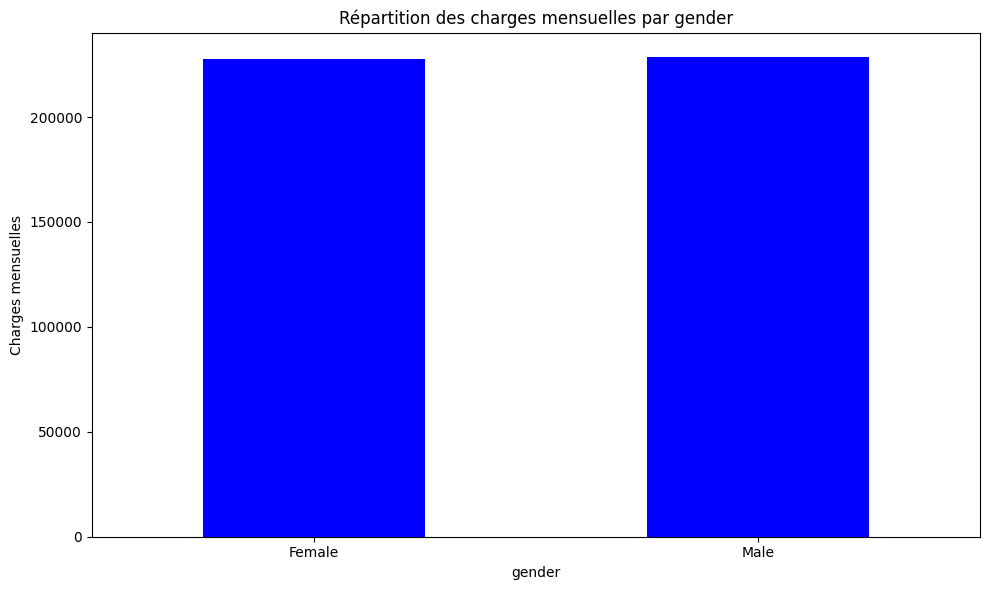

In [ ]:
Telco.groupby('gender')['MonthlyCharges'].sum().plot(kind = 'bar',color = 'blue',figsize= (10,6))
plt.title ('Répartition des charges mensuelles par gender')
plt.xlabel('gender')
plt.ylabel('Charges mensuelles')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

Interpretation: la barre des hommes est legerement plus haute par rapport celle des femmes , ce sont donc les hommes qui contribuent davantage aux revenus mensuels.

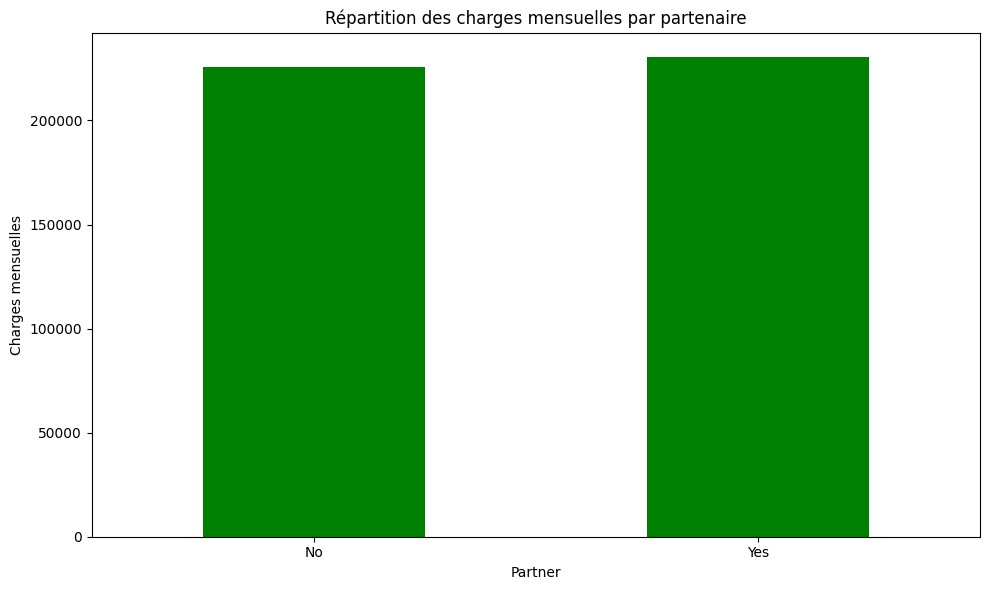

In [ ]:
Telco.groupby('Partner')['MonthlyCharges'].sum().plot(kind = 'bar',color = 'green',figsize= (10,6))
plt.title ('Répartition des charges mensuelles par partenaire')
plt.xlabel('Partner')
plt.ylabel('Charges mensuelles')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

Interpretation: les clients avec un partenaire génèrent au total plus de revenus mensuels que ceux sans partenaire.

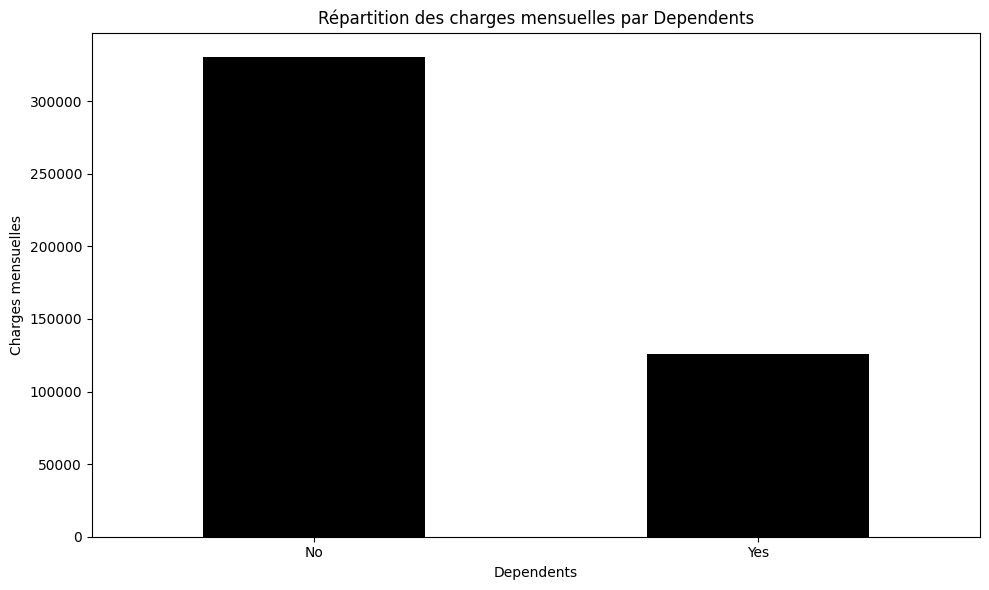

In [ ]:
Telco.groupby('Dependents')['MonthlyCharges'].sum().plot(kind = 'bar',color = 'black',figsize= (10,6))
plt.title ('Répartition des charges mensuelles par Dependents')
plt.xlabel('Dependents')
plt.ylabel('Charges mensuelles')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

Interpretation: les clients avec des dépendants paient moins de revenu mensuels par rapport à ceux sans dépendants.

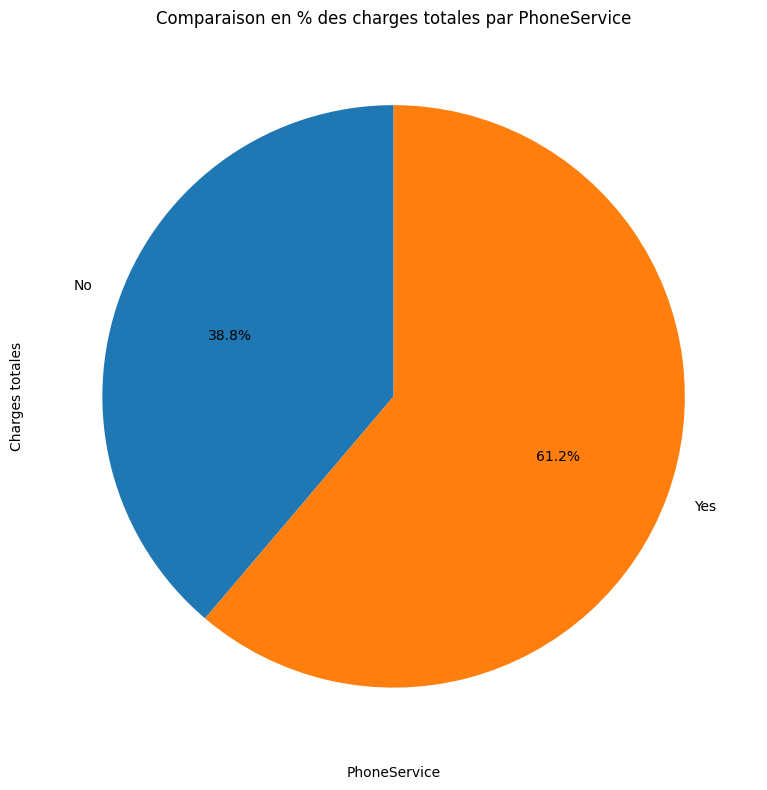

In [ ]:
Telco.groupby('PhoneService')['TotalCharges'].mean().plot(kind = 'pie',autopct = '%1.1f%%',startangle = 90,figsize= (12,8))
plt.title ('Comparaison en % des charges totales par PhoneService')
plt.xlabel('PhoneService')
plt.ylabel('Charges totales')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

Interpretation: 61,2% des clients qui utilisent le service telephonique ont plus de charges totales contre 38,8% des clients qui n'utilisent pas.

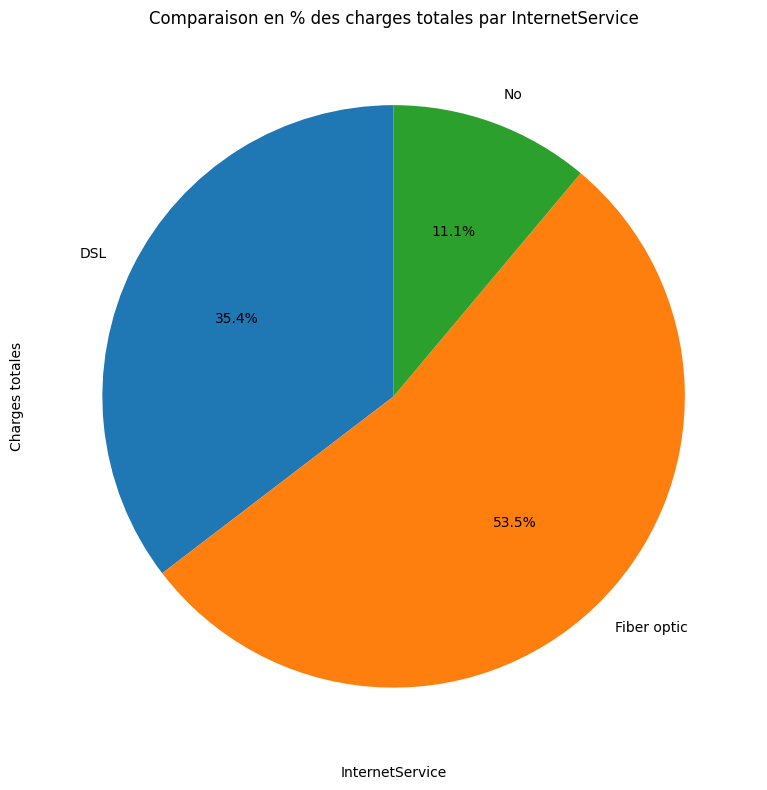

In [ ]:
Telco.groupby('InternetService')['TotalCharges'].mean().plot(kind = 'pie',autopct = '%1.1f%%',startangle = 90,figsize= (12,8))
plt.title ('Comparaison en % des charges totales par InternetService')
plt.xlabel('InternetService')
plt.ylabel('Charges totales')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

Interpretation: 53,5% des clients qui utilisent le service internet par Fibre optic, ont plus de charges totales contre 34,5% des clients DSL et 11,1% des clients qui utilisent aucun service internet .

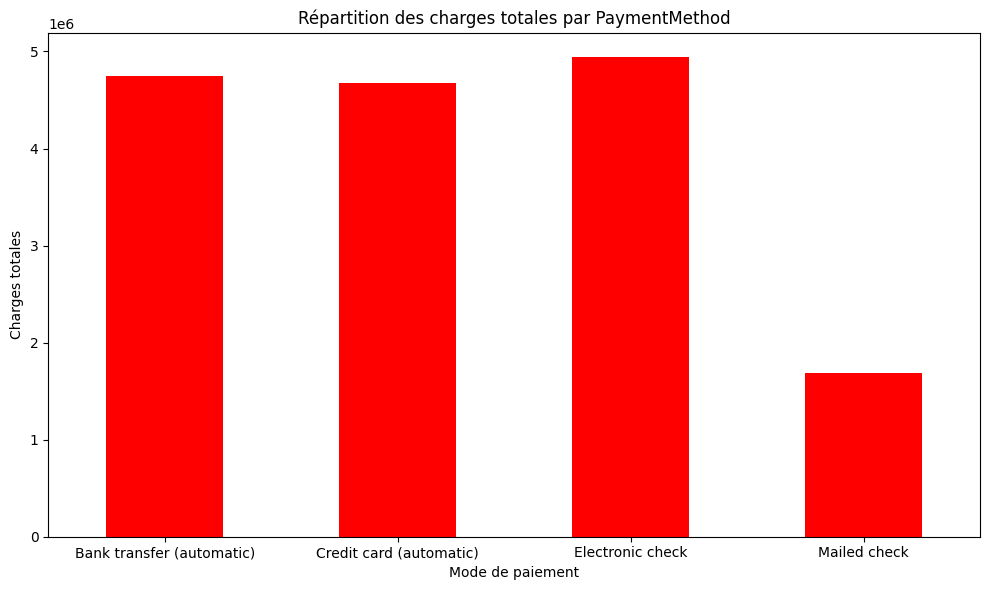

In [ ]:
Telco.groupby('PaymentMethod')['TotalCharges'].sum().plot(kind = 'bar',color = 'red',figsize= (10,6))
plt.title ('Répartition des charges totales par PaymentMethod')
plt.xlabel('Mode de paiement')
plt.ylabel('Charges totales')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

Interpretation: Les clients utilisant le mode de paiement par cheque electronique ont plus de charges totales.

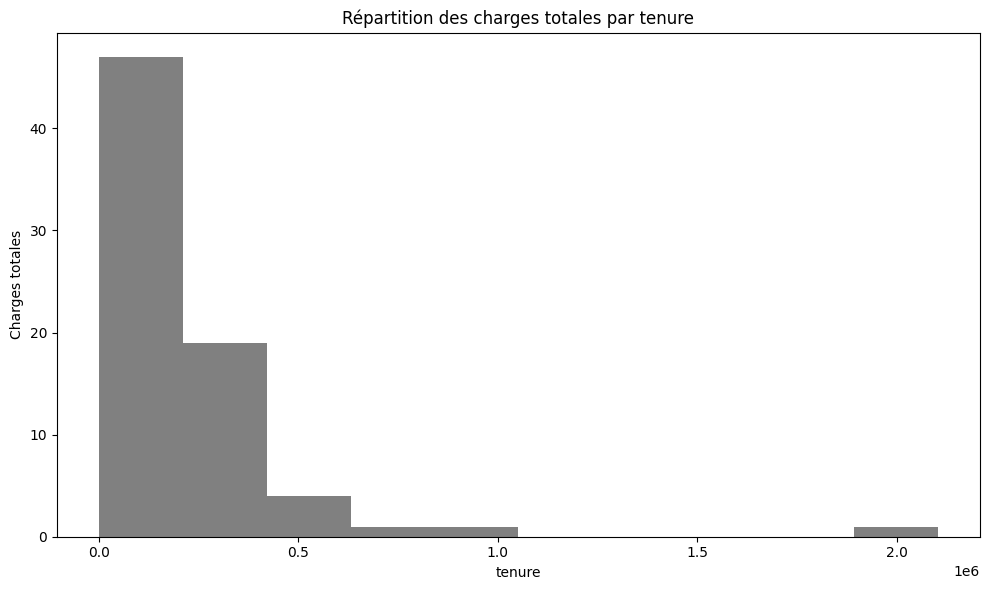

In [ ]:
Telco.groupby('tenure')['TotalCharges'].sum().plot(kind = 'hist',color = 'grey',figsize= (10,6))
plt.title ('Répartition des charges totales par tenure')
plt.xlabel('tenure')
plt.ylabel('Charges totales')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

Interpretation: Les clients ayant une plus longue ancienneté ont tendance à avoir des charges totales plus élevées. La plupart des clients ont des charges totales plus faibles, ce qui peut indiquer un plus grand nombre de clients récents ou à court terme, la fréquence diminuant à mesure que les charges totales et l'ancienneté augmentent.

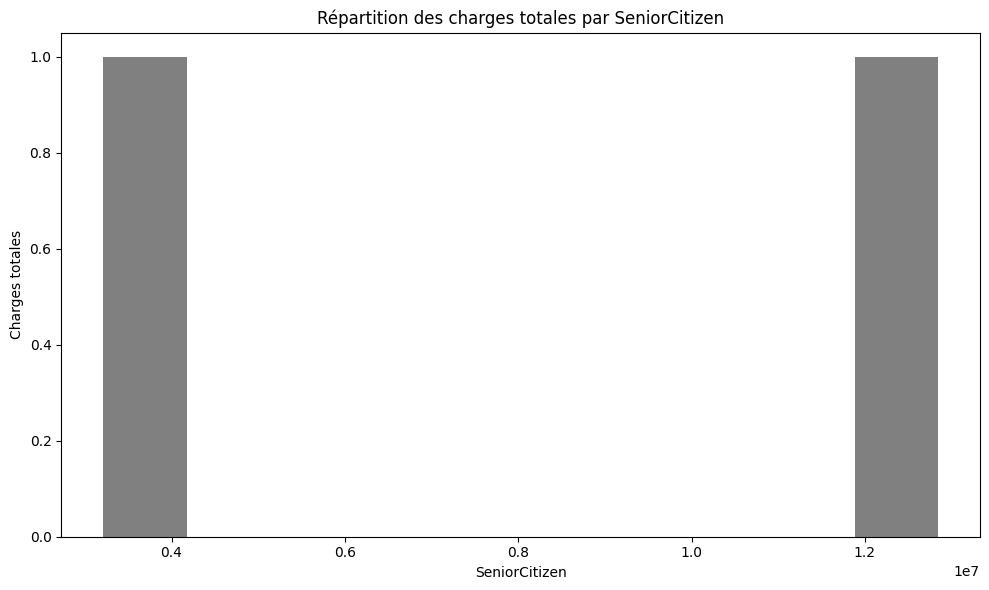

In [ ]:
Telco.groupby('SeniorCitizen')['TotalCharges'].sum().plot(kind = 'hist',color = 'grey',figsize= (10,6))
plt.title ('Répartition des charges totales par SeniorCitizen')
plt.xlabel('SeniorCitizen')
plt.ylabel('Charges totales')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

Interpretation: Il semble y avoir une distribution similaire des charges totales entre les deux groupes, bien que le nombre de clients non Senior soit plus élevé, ce qui entraîne des barres plus hautes dans cette catégorie, reflétant une plus grande population.

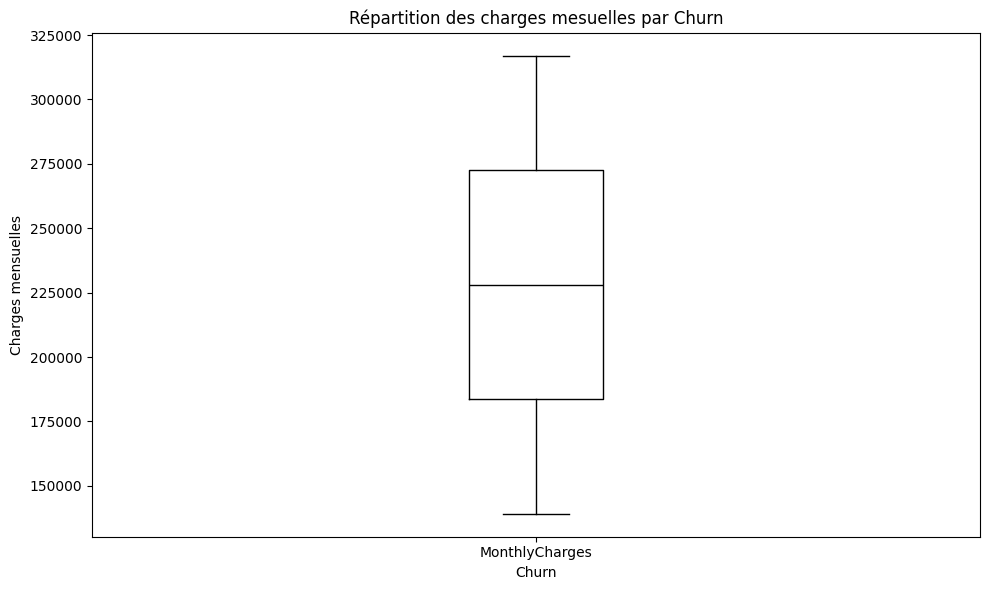

In [ ]:
Telco.groupby('Churn')['MonthlyCharges'].sum().plot(kind = 'box',color = 'black',figsize= (10,6))
plt.title ('Répartition des charges mesuelles par Churn')
plt.xlabel('Churn')
plt.ylabel('Charges mensuelles')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

Interpretation: les clients n'ayant pas résilié présentent une médiane et une étendue (interquartile range) des charges mensuelles plus élevées, suggérant qu'ils ont une ancienneté plus longue et, par conséquent, des dépenses cumulées plus importantes.

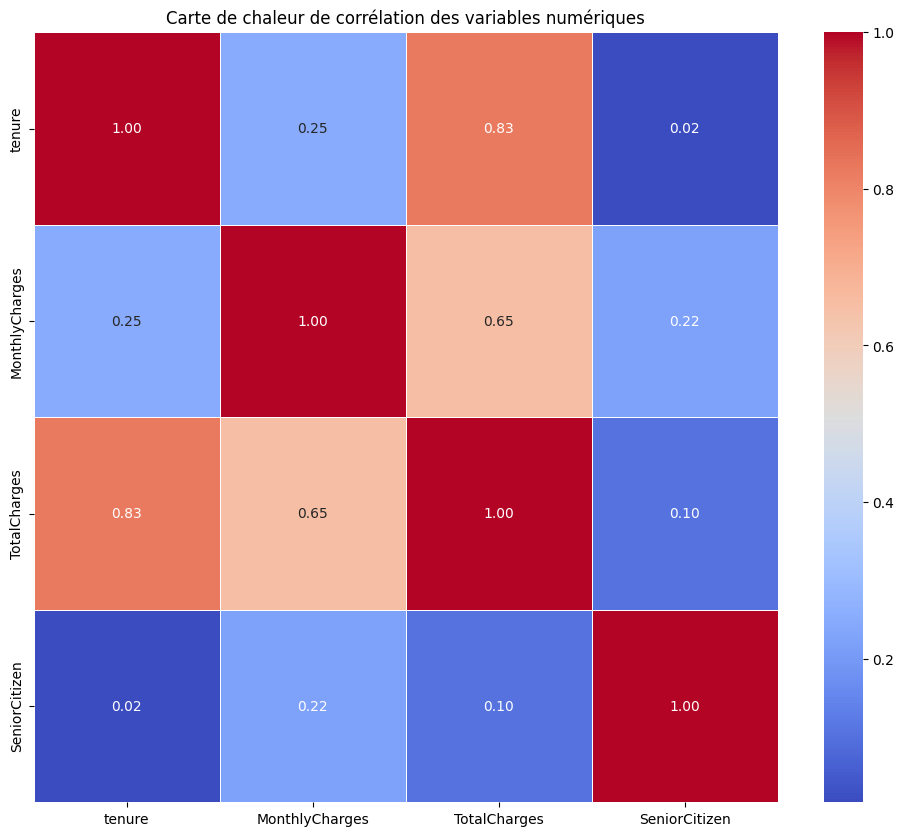

In [ ]:
Telco_numeric = Telco[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']]
correlation_matrix = Telco_numeric.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Carte de chaleur de corrélation des variables numériques')
plt.show()

Interpretation : Cette carte de chaleur de corrélation montre les relations linéaires entre les variables numériques. Des valeurs proches de 1 indiquent une forte corrélation positive, des valeurs proches de -1 indiquent une forte corrélation négative, et des valeurs proches de 0 indiquent une faible corrélation. Par exemple, 'tenure' et 'TotalCharges' devraient être fortement corrélées positivement, car plus un client reste longtemps (tenure), plus ses charges totales augmentent.



## Les risques commerciaux :
1- Attrition élevée dans certains segments : Les clients mensuels, les seniors et les utilisateurs fibre présentent un risque de désabonnement important, fragilisant la base de revenus.

2- Faiblesse des paiements par chèque électronique : Ce mode de paiement est associé à un taux d’attrition très élevé (45,3 %), révélant un engagement limité.

3- Dépendance à la fidélité long terme : Les clients récents génèrent peu de revenus, ce qui rend la croissance fortement dépendante de la rétention durable.

# Opportunités commerciales :
1- Fidélisation et migration de contrats : Encourager le passage des contrats mensuels vers des formules annuelles ou pluriannuelles pour stabiliser les revenus.

2- Offres ciblées pour segments à risque : Développer des services spécifiques pour seniors et clients fibre (support renforcé, promotions exclusives).

3- Promotion des paiements automatiques : Favoriser les virements bancaires ou cartes de crédit pour réduire l’attrition et améliorer la fidélisation.

## Conclusion : La fidélisation n’est pas qu’une question de prix, mais de structure de l’offre et expérience client.